In [ ]:
import pandas as pd              # 데이터 분석의 기본!
import seaborn as sns           # 예쁜 그래프 그리기
import matplotlib.pyplot as plt # 그래프 세부 설정


In [14]:
# 'data' 폴더 안에 있는 'train.csv'를 불러옵니다.
# 'data/' 부분을 추가해주는 것이 핵심입니다!
train = pd.read_csv('data/bike_train.csv')

# 데이터가 잘 불러와졌는지 확인하기 위해 앞부분 5줄만 출력해볼까요?
print("데이터 로딩 성공!")
print(train.head())

데이터 로딩 성공!
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


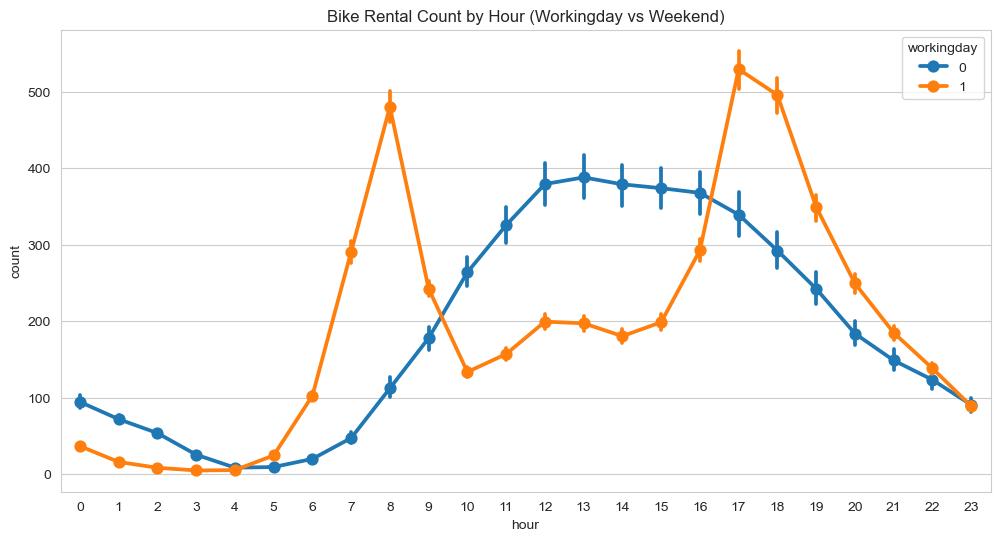

In [15]:
# datetime에서 hour 정보를 추출합니다 (앞서 했던 작업)
train['datetime'] = pd.to_datetime(train['datetime'])
train['hour'] = train['datetime'].dt.hour

# 시간대별(hour) 대여량(count)을 평일/주말(workingday)에 따라 그려봅니다.
plt.figure(figsize=(12, 6))
sns.pointplot(data=train, x='hour', y='count', hue='workingday')
plt.title('Bike Rental Count by Hour (Workingday vs Weekend)')
plt.show()

Text(0.5, 1.0, 'Average Rental Count by Season')

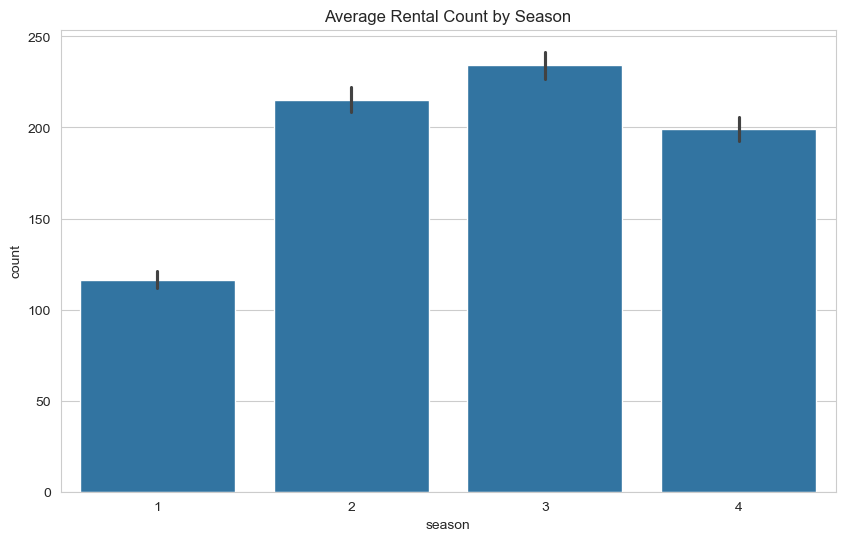

In [17]:
# 1. 계절별 대여량의 평균을 계산하여 막대 그래프로 그립니다.
sns.barplot(data=train, x='season', y='count')

# 2. 그래프의 제목을 설정합니다.
plt.title('Average Rental Count by Season')

In [18]:
# 1. 문자열인 datetime 컬럼을 컴퓨터가 계산 가능한 '날짜시간' 타입으로 바꿉니다.
train['datetime'] = pd.to_datetime(train['datetime'])

# 2. 변환된 데이터에서 '시간(hour)' 정보만 추출해 새로운 컬럼을 만듭니다.
train['hour'] = train['datetime'].dt.hour

In [16]:
from sklearn.model_selection import train_test_split

# 1. 사용할 특성(Feature)들만 선택합니다.
feature_names = ['temp', 'atemp', 'humidity', 'windspeed', 'workingday', 'hour']
X = train[feature_names] # 문제지

# 2. 맞혀야 할 정답(Target)을 선택합니다.
y = train['count'] # 정답지

# 3. 전체 데이터를 훈련용과 검증용으로 나눕니다.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("훈련용 문제지 개수:", X_train.shape)
print("검증용 문제지 개수:", X_val.shape)

훈련용 문제지 개수: (8708, 6)
검증용 문제지 개수: (2178, 6)
